# Customer Cohort and Retention Analysis

## 1. Objective

The previous exploratory analysis showed that approximately 97% of customers
placed only one delivered order, while repeat customers represented only
about 3% of the customer base.

This notebook uses cohort analysis to examine customer retention over time.

Customers are grouped by the month of their first delivered purchase, and
their subsequent purchasing activity is tracked across later months.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyodbc

server = r"LAPTOP-P3LI1TMH\SQLEXPRESS"
database = "ecommerce_analytics"

conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

print("Connected to SQL Server successfully!")

Connected to SQL Server successfully!


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyodbc

server = r"LAPTOP-P3LI1TMH\SQLEXPRESS"
database = "ecommerce_analytics"

conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

print("Connected to SQL Server successfully!")

Connected to SQL Server successfully!


## 2. Load Customer Order Data

Cohort analysis is performed at the order level.

Each record represents one delivered order associated with a unique customer
identifier and purchase timestamp.

In [13]:
orders_query = """
SELECT
    o.order_id,
    c.customer_unique_id,
    o.order_purchase_timestamp

FROM dbo.orders AS o

INNER JOIN dbo.customers AS c
    ON o.customer_id = c.customer_id

WHERE o.order_status = 'delivered'
  AND o.order_purchase_timestamp IS NOT NULL;
"""

orders_df = pd.read_sql(orders_query, conn)

orders_df["order_purchase_timestamp"] = pd.to_datetime(
    orders_df["order_purchase_timestamp"]
)

print("Orders:", len(orders_df))
print("Unique customers:", orders_df["customer_unique_id"].nunique())

orders_df.head()

C:\Users\pc\AppData\Local\Temp\ipykernel_14888\8152047.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_df = pd.read_sql(orders_query, conn)


Orders: 96478
Unique customers: 93358


,order_id,customer_unique_id,order_purchase_timestamp
0,00e7ee1b050b8499577073aeb2a297a1,861eff4711a542e4b93843c6dd7febb0,2017-05-16 15:05:35
1,29150127e6685892b6eab3eec79f59c7,290c77bc529b7ac935b93aa66c333dc3,2018-01-12 20:48:24
2,b2059ed67ce144a36e2aa97d2c9e9ad2,060e732b5b29e8181a18229c7b0b2b5e,2018-05-19 16:07:45
3,951670f92359f4fe4a63112aa7306eba,259dac757896d24d7702b9acbbff3f3c,2018-03-13 16:06:38
4,6b7d50bd145f6fc7f33cebabd7e49d0f,345ecd01c38d18a9036ed96c73b8d066,2018-07-29 09:51:30


## 3. Cohort Assignment

Each customer is assigned to a cohort based on the month of their first
delivered purchase.

`cohort_index` represents the number of months elapsed since the customer's
first purchase:

- 0 = acquisition month
- 1 = one month after acquisition
- 2 = two months after acquisition
- and so on

In [14]:
# Create order month

orders_df["order_month"] = (
    orders_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Identify each customer's first purchase month

orders_df["cohort_month"] = (
    orders_df
    .groupby("customer_unique_id")["order_month"]
    .transform("min")
)

# Calculate number of months since first purchase

year_diff = (
    orders_df["order_month"].dt.year
    - orders_df["cohort_month"].dt.year
)

month_diff = (
    orders_df["order_month"].dt.month
    - orders_df["cohort_month"].dt.month
)

orders_df["cohort_index"] = (
    year_diff * 12 + month_diff
)

orders_df[
    [
        "customer_unique_id",
        "order_month",
        "cohort_month",
        "cohort_index"
    ]
].head(10)

,customer_unique_id,order_month,cohort_month,cohort_index
0,861eff4711a542e4b93843c6dd7febb0,2017-05-01,2017-05-01,0
1,290c77bc529b7ac935b93aa66c333dc3,2018-01-01,2018-01-01,0
2,060e732b5b29e8181a18229c7b0b2b5e,2018-05-01,2018-05-01,0
3,259dac757896d24d7702b9acbbff3f3c,2018-03-01,2018-03-01,0
4,345ecd01c38d18a9036ed96c73b8d066,2018-07-01,2018-07-01,0
5,4c93744516667ad3b8f1fb645a3116a4,2017-09-01,2017-09-01,0
6,addec96d2e059c80c30fe6871d30d177,2018-02-01,2018-02-01,0
7,57b2a98a409812fe9618067b6b8ebe4f,2017-11-01,2017-11-01,0
8,1175e95fb47ddff9de6b2b06188f7e0d,2018-01-01,2018-01-01,0
9,9afe194fb833f79e300e37e580171f22,2018-01-01,2018-01-01,0


## 4. Retention Matrix

The main retention analysis focuses on cohorts beginning in January 2017.

Very early cohorts contain extremely small customer counts and are excluded
from the visualization to avoid unstable retention percentages.

The original first-purchase dates are preserved before applying this filter.

In [20]:
# Count unique active customers by cohort and month since acquisition

cohort_counts = (
    cohort_df
    .groupby(
        ["cohort_month", "cohort_index"]
    )["customer_unique_id"]
    .nunique()
    .unstack(fill_value=0)
)

# Ensure all month indices are present
max_cohort_index = orders_df["cohort_index"].max()

cohort_counts = cohort_counts.reindex(
    columns=range(max_cohort_index + 1),
    fill_value=0
)

# Cohort size = customers in acquisition month
cohort_sizes = cohort_counts[0]

# Convert counts to retention rates
retention_matrix = (
    cohort_counts
    .divide(cohort_sizes, axis=0)
    * 100
)

retention_matrix.round(2)

cohort_index,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,,
2017-01-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,0.00,...,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.0,0.14,0.0
2017-02-01,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,...,0.31,0.12,0.18,0.12,0.06,0.06,0.18,0.0,0.00,0.0
2017-03-01,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,...,0.12,0.20,0.12,0.16,0.24,0.08,0.12,0.0,0.00,0.0
2017-04-01,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,...,0.09,0.04,0.04,0.09,0.09,0.13,0.00,0.0,0.00,0.0
2017-05-01,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,...,0.35,0.23,0.03,0.17,0.20,0.00,0.00,0.0,0.00,0.0
2017-06-01,100.0,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,...,0.36,0.16,0.16,0.23,0.00,0.00,0.00,0.0,0.00,0.0
2017-07-01,100.0,0.53,0.35,0.24,0.29,0.21,0.32,0.11,0.19,0.27,...,0.29,0.13,0.24,0.00,0.00,0.00,0.00,0.0,0.00,0.0
2017-08-01,100.0,0.69,0.35,0.27,0.35,0.52,0.30,0.27,0.15,0.15,...,0.20,0.12,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0
2017-09-01,100.0,0.70,0.55,0.27,0.45,0.22,0.22,0.25,0.27,0.17,...,0.07,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0


In [23]:
# Mask periods that were not yet observable
# while preserving all cohort index columns

retention_matrix_clean = retention_matrix.copy()

max_order_month = orders_df["order_month"].max()

for cohort_month in retention_matrix_clean.index:

    max_observable_index = (
        (max_order_month.year - cohort_month.year) * 12
        + (max_order_month.month - cohort_month.month)
    )

    future_columns = [
        col for col in retention_matrix_clean.columns
        if col > max_observable_index
    ]

    retention_matrix_clean.loc[
        cohort_month,
        future_columns
    ] = np.nan

print(
    "Clean retention columns:",
    retention_matrix_clean.columns.tolist()
)

retention_matrix_clean.round(2)

Clean retention columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


cohort_index,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,,
2017-01-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,0.00,...,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.0,0.14,NaN
2017-02-01,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,...,0.31,0.12,0.18,0.12,0.06,0.06,0.18,0.0,NaN,NaN
2017-03-01,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,...,0.12,0.20,0.12,0.16,0.24,0.08,0.12,NaN,NaN,NaN
2017-04-01,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,...,0.09,0.04,0.04,0.09,0.09,0.13,NaN,NaN,NaN,NaN
2017-05-01,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,...,0.35,0.23,0.03,0.17,0.20,NaN,NaN,NaN,NaN,NaN
2017-06-01,100.0,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,...,0.36,0.16,0.16,0.23,NaN,NaN,NaN,NaN,NaN,NaN
2017-07-01,100.0,0.53,0.35,0.24,0.29,0.21,0.32,0.11,0.19,0.27,...,0.29,0.13,0.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-01,100.0,0.69,0.35,0.27,0.35,0.52,0.30,0.27,0.15,0.15,...,0.20,0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,100.0,0.70,0.55,0.27,0.45,0.22,0.22,0.25,0.27,0.17,...,0.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


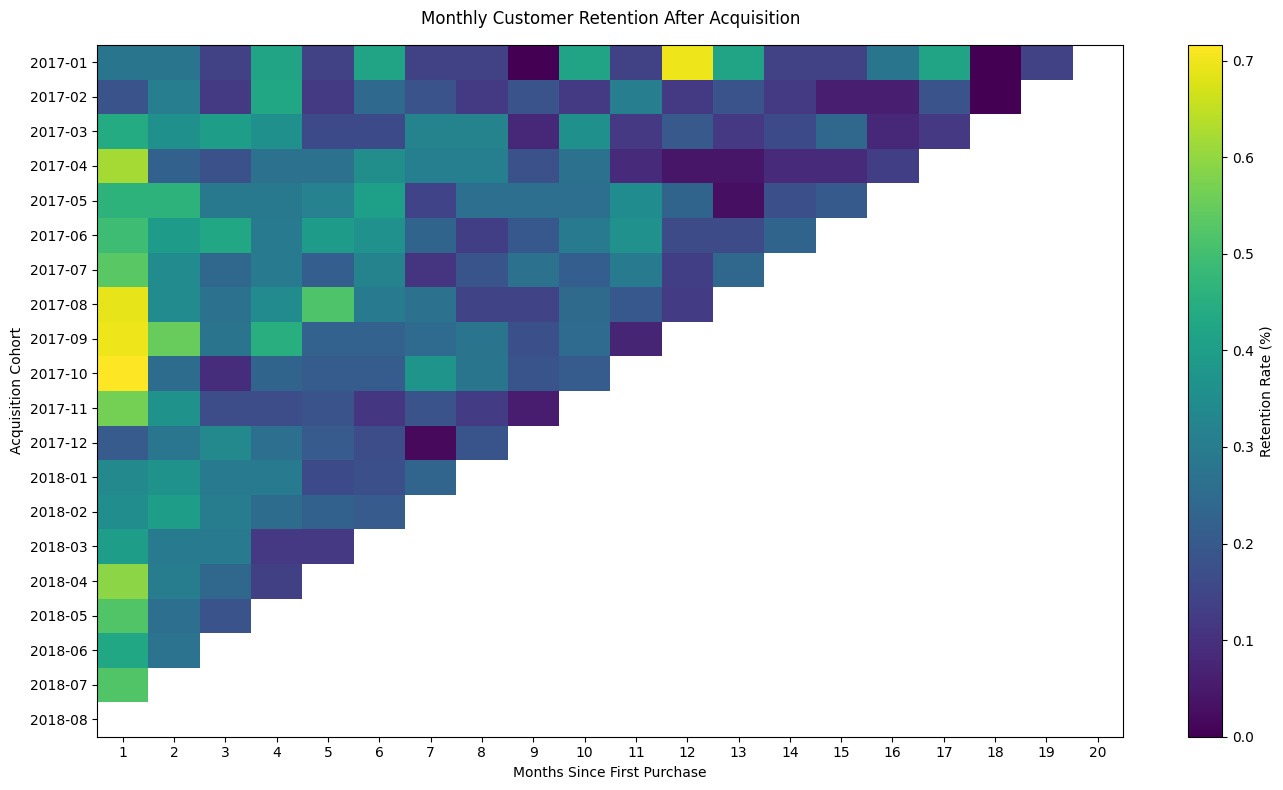

In [24]:
# Visualize retention after the acquisition month

retention_plot = retention_matrix_clean.drop(
    columns=0
)

masked_retention = np.ma.masked_invalid(
    retention_plot.values
)

fig, ax = plt.subplots(figsize=(14, 8))

heatmap = ax.imshow(
    masked_retention,
    aspect="auto"
)

ax.set_title(
    "Monthly Customer Retention After Acquisition",
    pad=15
)

ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Acquisition Cohort")

ax.set_xticks(
    range(len(retention_plot.columns))
)

ax.set_xticklabels(
    retention_plot.columns
)

ax.set_yticks(
    range(len(retention_plot.index))
)

ax.set_yticklabels(
    retention_plot.index.strftime("%Y-%m")
)

cbar = plt.colorbar(
    heatmap,
    ax=ax
)

cbar.set_label("Retention Rate (%)")

plt.tight_layout()
plt.show()

## 5. Retention Metrics

Retention is summarized across cohorts using both simple average retention
and weighted retention.

Weighted retention gives larger cohorts more influence and therefore provides
a more representative view of retention across the overall customer base.

In [17]:
# Calculate average retention across cohorts

average_retention = (
    retention_matrix_clean
    .drop(columns=0)
    .mean(axis=0, skipna=True)
)

average_retention.round(2)

cohort_index
1     0.48
2     0.34
3     0.25
4     0.29
5     0.23
6     0.26
7     0.21
8     0.21
9     0.16
10    0.26
11    0.21
12    0.21
13    0.17
14    0.15
15    0.15
16    0.14
17    0.24
19    0.14
dtype: float64

In [18]:
# Calculate weighted retention across cohorts

weighted_retention = {}

for cohort_index in retention_matrix_clean.columns[1:]:

    valid_cohorts = retention_matrix_clean[
        cohort_index
    ].notna()

    active_customers = cohort_counts.loc[
        valid_cohorts,
        cohort_index
    ].sum()

    eligible_customers = cohort_sizes.loc[
        valid_cohorts
    ].sum()

    weighted_retention[cohort_index] = (
        active_customers / eligible_customers * 100
        if eligible_customers > 0
        else np.nan
    )

weighted_retention = pd.Series(
    weighted_retention,
    name="retention_rate_pct"
)

weighted_retention.round(2)

1     0.48
2     0.34
3     0.26
4     0.26
5     0.23
6     0.23
7     0.21
8     0.20
9     0.16
10    0.25
11    0.22
12    0.17
13    0.14
14    0.16
15    0.16
16    0.11
17    0.19
19    0.14
Name: retention_rate_pct, dtype: float64

## 6. Final Findings

The cohort analysis confirms that customer retention is very low across
the observed period.

### Early Retention

Weighted Month-1 retention is approximately 0.48%, meaning that fewer than
1% of eligible customers made another delivered purchase in the month
immediately following their first purchase.

Retention decreases further during the following months:

- Month 1: approximately 0.48%
- Month 2: approximately 0.34%
- Month 3: approximately 0.26%

This indicates that repeat purchasing shortly after customer acquisition
is uncommon.

### Cohort Pattern

Retention after the acquisition month generally remains below 1% across
cohorts.

Although some acquisition cohorts perform slightly better than others,
none shows consistently strong retention over time.

This supports the earlier exploratory analysis finding that the customer
base is heavily dominated by one-time buyers.

### Business Interpretation

The observed purchasing pattern suggests that revenue depends heavily on
continued customer acquisition rather than frequent repeat purchasing from
existing customers.

Customer retention therefore represents an important area for further
investigation. Future analysis could examine which product categories,
customer groups, or purchase experiences are associated with repeat
purchasing behavior.

### Analytical Caution

Later retention periods are based on fewer eligible cohorts because newer
customers have not had enough time to reach those lifecycle months.

Long-term retention rates should therefore be interpreted more cautiously
than early-period retention metrics.

In [25]:
# Close the SQL Server connection

conn.close()

print("SQL Server connection closed.")

SQL Server connection closed.
